In [7]:
import os
os.listdir('/content')


['.config', 'sample_data']

In [9]:
import pandas as pd
df=pd.read_csv("Sample - Superstore.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
print("Ready:", df.shape)

Saving Sample - Superstore.csv to Sample - Superstore.csv
Ready: (9994, 22)


In [10]:
df.shape

(9994, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [14]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


Technology drives the most revenue at rs836K, but it's only 3 products away from Office Supplies. Furniture is surprisingly close despite being bulky, low-frequency purchases."

In [15]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


furniture generates 27% of revenue but only 6% of total profit ,suggesting deep discount or cost problems worth investingating.

In [16]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


In [17]:
df[df['Sub-Category'] == 'Tables'][['Discount','Profit']].describe()

,Discount,Profit
count,319.000000,319.000000
mean,0.261285,-55.565771
std,0.169622,230.565006
min,0.000000,-1862.312400
25%,0.200000,-122.829300
50%,0.300000,-31.372200
75%,0.400000,33.851700
max,0.500000,629.010000


Tables are the company's worst product. 319 transactions averaging a 26% discount produces a Rs55 loss per sale. The discount strategy is destroying margin. Recommendation: cap Table discounts at 10% or discontinue the product line.


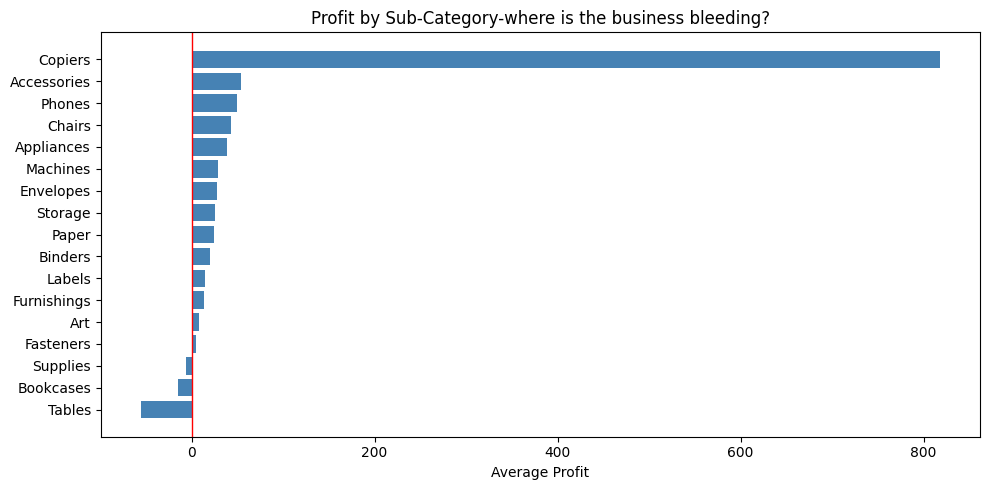

In [18]:
import matplotlib.pyplot as plt
discount_profit = df.groupby('Sub-Category')[['Discount','Profit']].mean().sort_values('Profit')
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.barh(discount_profit.index ,discount_profit['Profit'],color='steelblue')
ax1.axvline(0,color='red',linewidth=1)
ax1.set_xlabel('Average Profit')
ax1.set_title('Profit by Sub-Category-where is the business bleeding?')
plt.tight_layout()
plt.show()

In [29]:
df.groupby('Region')[['Discount', 'Profit']].sum()

,Discount,Profit
Region,,
Central,558.34,39706.3625
East,414.00,91522.7800
South,238.55,46749.4303
West,350.20,108418.4489


west region has most profit

In [20]:
df.groupby('Category')[['Discount','Profit']].mean()

,Discount,Profit
Category,,
Furniture,0.173923,8.699327
Office Supplies,0.157285,20.327050
Technology,0.132323,78.752002


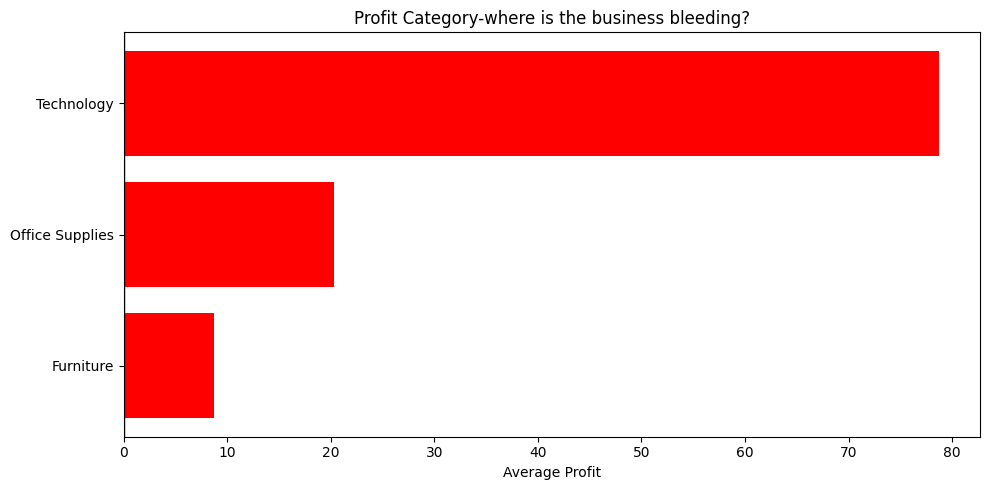

In [21]:
import matplotlib.pyplot as plt
discount_profit = df.groupby('Category')[['Discount','Profit']].mean().sort_values('Profit')
fig, ax1 =plt.subplots(figsize=(10,5))
ax1.barh(discount_profit.index,discount_profit['Profit'],color='red')
ax1.axvline(0,color='blue',linewidth=1)
ax1.set_xlabel('Average Profit')
ax1.set_title('Profit Category-where is the business bleeding?')
plt.tight_layout()
plt.show()

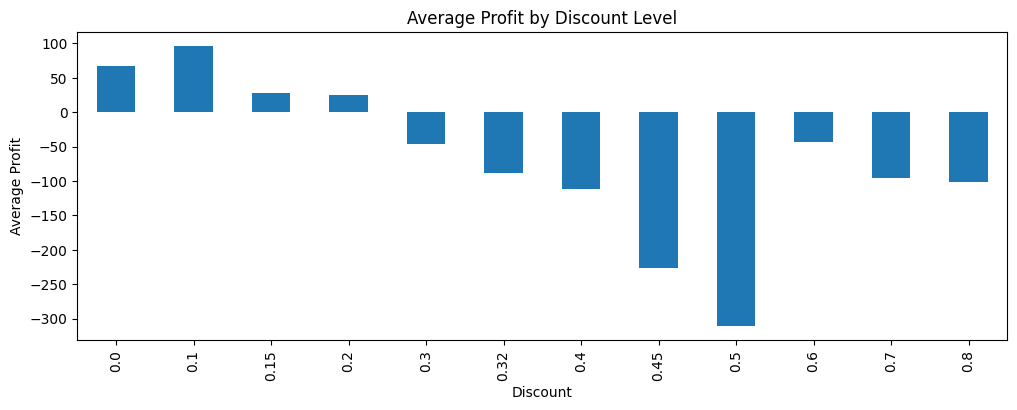

In [22]:
df.groupby('Discount')['Profit'].mean().plot(kind='bar',figsize=(12,4), title='Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.show()

"Discounts above 20% destroy profit — the company is literally paying customers to take their products at 45-50% discount levels."



In [23]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571


top 5 customer by total sale

In [25]:

df.groupby('State')['Profit'].sum().sort_values().head(5)

,Profit
State,
Texas,-25729.3563
Ohio,-16971.3766
Pennsylvania,-15559.9603
Illinois,-12607.8870
North Carolina,-7490.9122


Texas alone loses $25K in profit, more than the bottom 4 states combined — a geographic pricing or discount problem that needs immediate investigation."

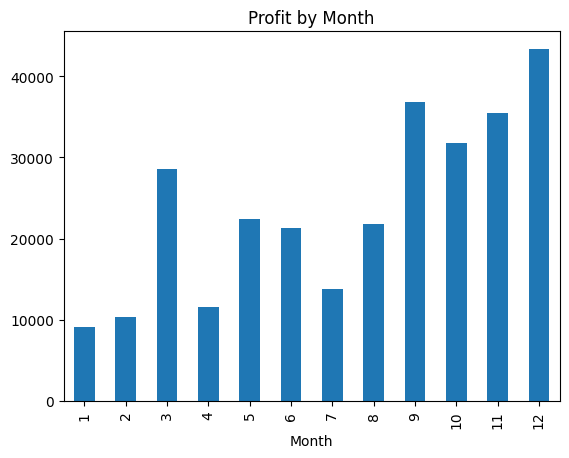

In [27]:
import matplotlib.pyplot as plt
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df.groupby('Month')['Profit'].sum().plot(kind='bar',title='Profit by Month')
plt.show()

The business makes 35% of its annual profit in the last 3 months — January and February are so weak the company should cut costs or run promotions in Q1 to survive the drought."

In [31]:
import plotly.express as px
fig= px.bar(
    df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values('Profit'),
    x='Profit',
    y='Sub-Category',
    orientation='h',
    color='Profit',
    color_continuous_scale='RdYlGn',
    title='Profit by subcategory-Green is good ,Red is bleeding'
)
fig.show()

In [12]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

region_profit = df.groupby('Region')['Profit'].sum().reset_index()
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

fig = make_subplots(rows=2, cols=2, subplot_titles=['Profit by Region', 'Sales by Category', 'Profit by Month', 'Discount vs Profit'])

fig.add_trace(go.Bar(x=region_profit['Region'], y=region_profit['Profit'], marker_color='steelblue'), row=1, col=1)
fig.add_trace(go.Bar(x=category_sales['Category'], y=category_sales['Sales'], marker_color='coral'), row=1, col=2)
fig.add_trace(go.Bar(x=monthly_profit['Month'], y=monthly_profit['Profit'], marker_color='green'), row=2, col=1)
fig.add_trace(go.Scatter(x=discount_profit['Discount'], y=discount_profit['Profit'], mode='lines+markers', marker_color='red'), row=2, col=2)

fig.update_layout(height=600, title_text='Superstore Business Dashboard', showlegend=False)
fig.show()